# Smart Outcome Predictor — Complete Project Notebook



## Part A - Conceptual Foundation

**1. Ensemble Learning Methods:** Ensemble learning combines predictions from several models instead of relying on one model. It can improve stability, reduce errors, and generalize better when the individual models make different mistakes.

**2. Bagging, Boosting, and Voting:** Bagging trains models independently on different bootstrap samples and averages their results. Boosting builds models one after another so later models focus more on previous errors. Voting combines predictions from different models using majority voting or averaged probabilities.

**3. Bias-Variance Trade-off:** High bias means the model is too simple, while high variance means it changes a lot with the training data. Ensemble methods can reduce variance through averaging and can also reduce bias by combining several useful learners.

**4. Voting Classifier and Stacking:** Voting makes a final decision directly from several base classifiers. Stacking first collects predictions from base models and then gives those predictions to a meta-learner that learns how to combine them.

**5. AdaBoost vs Gradient Boosting vs LightGBM vs XGBoost:** AdaBoost gives more attention to incorrectly predicted observations. Gradient Boosting adds trees sequentially to reduce the loss. LightGBM is designed for fast, memory-efficient tree boosting. XGBoost is another optimized gradient boosting method with strong regularization and practical performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    VotingClassifier, StackingClassifier, StackingRegressor,
    RandomForestClassifier, RandomForestRegressor
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor

DATA_FILE = "dataset.csv"
df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


## Part B - Dataset Understanding & Preparation

The supplied file contains student demographic fields, engagement fields, assessment fields, and the two requested targets.

For a fair prediction setup, `student_id` is removed because it is only an identifier. For the **classification** task, `final_score` is not used as a feature because it is the other outcome. For the **regression** task, `completion_status` is not used for the same reason. This avoids target leakage.

The date is converted to month and day features, and the original date column is removed.


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget counts:")
print(df["completion_status"].value_counts())

df["course_start_date"] = pd.to_datetime(df["course_start_date"])
df["start_month"] = df["course_start_date"].dt.month
df["start_day"] = df["course_start_date"].dt.day
df = df.drop(columns=["course_start_date"])

common_drop = ["student_id"]
classification_features = [
    c for c in df.columns
    if c not in common_drop + ["completion_status", "final_score"]
]
regression_features = [
    c for c in df.columns
    if c not in common_drop + ["completion_status", "final_score"]
]

X_class = df[classification_features]
y_class = df["completion_status"]

X_reg = df[regression_features]
y_reg = df["final_score"]

print("\nClassification features:", len(classification_features))
print(classification_features)

print("\nRegression features:", len(regression_features))
print(regression_features)


Columns:
['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']

Missing values:
student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

Target counts:
completion_status
0    3248
1    1952
Name: count, dtype: int64

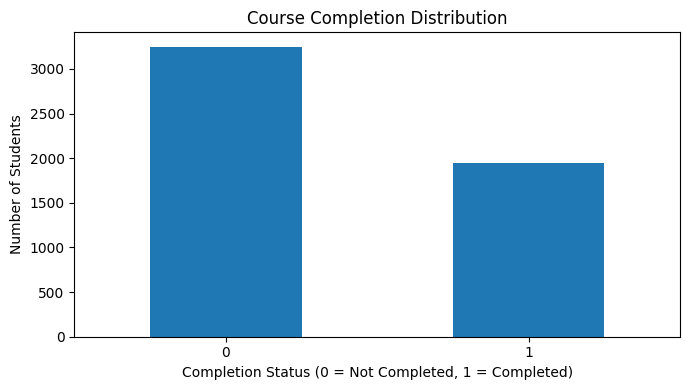

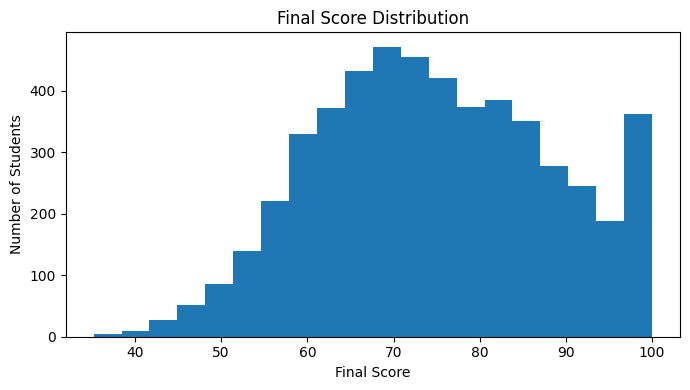

In [ ]:



plt.figure(figsize=(7, 4))
df["completion_status"].value_counts().sort_index().plot(kind="bar")
plt.title("Course Completion Distribution")
plt.xlabel("Completion Status (0 = Not Completed, 1 = Completed)")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df["final_score"], bins=20)
plt.title("Final Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


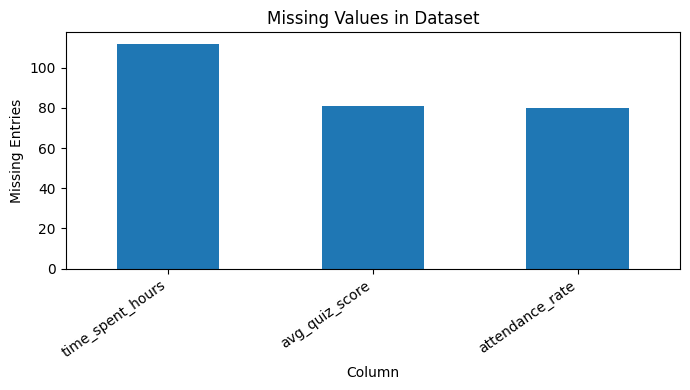

Missing-value handling: median imputation for numeric columns and most-frequent imputation for categorical columns.


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(7, 4))
missing.plot(kind="bar")
plt.title("Missing Values in Dataset")
plt.xlabel("Column")
plt.ylabel("Missing Entries")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("Missing-value handling: median imputation for numeric columns and most-frequent imputation for categorical columns.")


In [ ]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.20, random_state=42, stratify=y_class
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

num_cols = [c for c in X_class.columns if X_class[c].dtype != "object"]
cat_cols = [c for c in X_class.columns if X_class[c].dtype == "object"]

def make_preprocessor(scale=False):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(num_steps)

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

pre_tree = make_preprocessor(False)
pre_scaled = make_preprocessor(True)

print("Classification train/test:", Xc_train.shape, Xc_test.shape)
print("Regression train/test:", Xr_train.shape, Xr_test.shape)


Classification train/test: (4160, 17) (1040, 17)
Regression train/test: (4160, 17) (1040, 17)


## Part C - Bagging

A single decision tree is used as the base reference. Bagging then trains multiple trees on bootstrap samples and combines their predictions. This gives a direct comparison between one model and an ensemble of similar models.


In [6]:
single_tree = Pipeline([
    ("prep", pre_tree),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

bagging_class = Pipeline([
    ("prep", pre_tree),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=40,
        random_state=42,
        n_jobs=-1
    ))
])

single_tree.fit(Xc_train, yc_train)
bagging_class.fit(Xc_train, yc_train)

pred_tree = single_tree.predict(Xc_test)
pred_bag = bagging_class.predict(Xc_test)

print("Single tree accuracy:", round(accuracy_score(yc_test, pred_tree), 4))
print("Bagging accuracy:", round(accuracy_score(yc_test, pred_bag), 4))
print("Bagging improves the single-tree baseline in this dataset.")


Single tree accuracy: 0.7029
Bagging accuracy: 0.7298
Bagging improves the single-tree baseline in this dataset.


In [7]:
single_reg = Pipeline([
    ("prep", pre_tree),
    ("model", DecisionTreeRegressor(max_depth=6, random_state=42))
])

bagging_reg = Pipeline([
    ("prep", pre_tree),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
        n_estimators=40,
        random_state=42,
        n_jobs=-1
    ))
])

single_reg.fit(Xr_train, yr_train)
bagging_reg.fit(Xr_train, yr_train)

pred_tree_r = single_reg.predict(Xr_test)
pred_bag_r = bagging_reg.predict(Xr_test)

print("Single tree MAE:", round(mean_absolute_error(yr_test, pred_tree_r), 4))
print("Bagging MAE:", round(mean_absolute_error(yr_test, pred_bag_r), 4))
print("Bagging reduces the average absolute error compared with the single tree.")


Single tree MAE: 8.7143
Bagging MAE: 8.1022
Bagging reduces the average absolute error compared with the single tree.


## Part D - Boosting Algorithms

The following models are implemented for both target types:

- AdaBoost
- Gradient Boosting
- LightGBM
- XGBoost

For interpretation, the notebook also checks how AdaBoost changes as the number of estimators changes and how Gradient Boosting changes with learning rate.


In [8]:
classification_models = {
    "Single Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Bagging Classifier": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=40, random_state=42, n_jobs=-1
    ),
    "AdaBoost Classifier": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=80, learning_rate=0.7, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.08, max_depth=2, random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=120, learning_rate=0.06, num_leaves=20,
        random_state=42, verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, learning_rate=0.06, max_depth=3,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1
    )
}

regression_models = {
    "Single Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Bagging Regressor": BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
        n_estimators=40, random_state=42, n_jobs=-1
    ),
    "AdaBoost Regressor": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        n_estimators=80, learning_rate=0.05, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=20,
        random_state=42, verbosity=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=120, learning_rate=0.05, max_depth=3,
        subsample=0.9, colsample_bytree=0.9,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    )
}

print("Boosting models are ready.")


Boosting models are ready.


In [ ]:
classification_results = []

for name, model in classification_models.items():
    pipe = Pipeline([
        ("prep", pre_tree),
        ("model", model)
    ])
    pipe.fit(Xc_train, yc_train)

    pred = pipe.predict(Xc_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        prob = pipe.predict_proba(Xc_test)[:, 1]
        roc_value = roc_auc_score(yc_test, prob)
    else:
        roc_value = np.nan

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred, zero_division=0),
        "Recall": recall_score(yc_test, pred, zero_division=0),
        "F1": f1_score(yc_test, pred, zero_division=0),
        "ROC_AUC": roc_value
    })

classification_results = pd.DataFrame(classification_results)
classification_results


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Single Decision Tree,0.702885,0.658824,0.430769,0.520930,0.754680
1,Bagging Classifier,0.729808,0.669782,0.551282,0.604782,0.779420
2,AdaBoost Classifier,0.727885,0.666667,0.548718,0.601969,0.785189
3,Gradient Boosting,0.738462,0.685535,0.558974,0.615819,0.792026
4,LightGBM,0.728846,0.668750,0.548718,0.602817,0.780935
5,XGBoost,0.736538,0.672619,0.579487,0.622590,0.789842


,n_estimators,Accuracy,F1,ROC_AUC
0,20,0.725000,0.584302,0.781134
1,40,0.729808,0.599144,0.784282
2,80,0.727885,0.601969,0.785189
3,120,0.729808,0.603667,0.786682


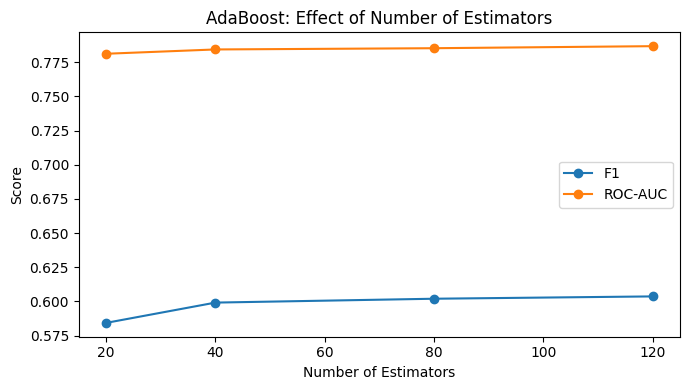

In [ ]:
ada_rows = []

for n in [20, 40, 80, 120]:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n, learning_rate=0.7, random_state=42
    )
    pipe = Pipeline([("prep", pre_tree), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)
    prob = pipe.predict_proba(Xc_test)[:, 1]

    ada_rows.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(yc_test, pred),
        "F1": f1_score(yc_test, pred),
        "ROC_AUC": roc_auc_score(yc_test, prob)
    })

ada_analysis = pd.DataFrame(ada_rows)
display(ada_analysis)

plt.figure(figsize=(7,4))
plt.plot(ada_analysis["n_estimators"], ada_analysis["F1"], marker="o", label="F1")
plt.plot(ada_analysis["n_estimators"], ada_analysis["ROC_AUC"], marker="o", label="ROC-AUC")
plt.title("AdaBoost: Effect of Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


,learning_rate,Accuracy,F1,ROC_AUC
0,0.03,0.723077,0.572700,0.785264
1,0.06,0.734615,0.605714,0.790655
2,0.10,0.738462,0.622222,0.792915
3,0.15,0.738462,0.622222,0.792655


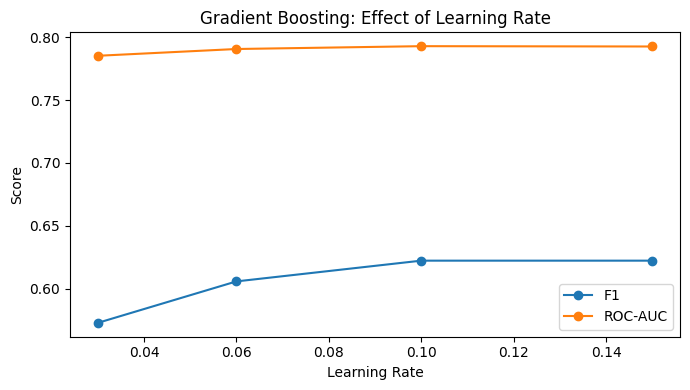

In [11]:
gb_rows = []

for lr in [0.03, 0.06, 0.10, 0.15]:
    model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=lr, max_depth=2, random_state=42
    )
    pipe = Pipeline([("prep", pre_tree), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)
    prob = pipe.predict_proba(Xc_test)[:, 1]

    gb_rows.append({
        "learning_rate": lr,
        "Accuracy": accuracy_score(yc_test, pred),
        "F1": f1_score(yc_test, pred),
        "ROC_AUC": roc_auc_score(yc_test, prob)
    })

gb_analysis = pd.DataFrame(gb_rows)
display(gb_analysis)

plt.figure(figsize=(7,4))
plt.plot(gb_analysis["learning_rate"], gb_analysis["F1"], marker="o", label="F1")
plt.plot(gb_analysis["learning_rate"], gb_analysis["ROC_AUC"], marker="o", label="ROC-AUC")
plt.title("Gradient Boosting: Effect of Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
regression_results = []

for name, model in regression_models.items():
    pipe = Pipeline([
        ("prep", pre_tree),
        ("model", model)
    ])
    pipe.fit(Xr_train, yr_train)

    pred = pipe.predict(Xr_test)

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(yr_test, pred),
        "RMSE": np.sqrt(mean_squared_error(yr_test, pred)),
        "R2": r2_score(yr_test, pred)
    })

regression_results = pd.DataFrame(regression_results)
regression_results


,Model,MAE,RMSE,R2
0,Single Decision Tree,8.714326,10.803143,0.375358
1,Bagging Regressor,8.102169,10.069577,0.457308
2,AdaBoost Regressor,8.567058,10.536155,0.405851
3,Gradient Boosting,8.072889,10.044757,0.459980
4,LightGBM,7.915082,9.887749,0.476730
5,XGBoost,7.900402,9.854356,0.480258


## Part E - Voting and Stacking

Voting is tested in two forms:

- **Hard voting:** majority decision from the base classifiers.
- **Soft voting:** average the predicted probabilities.

Stacking uses several base models and a Logistic Regression meta-learner for classification. For regression, a Ridge model is used as the meta-learner.


In [13]:
base_classifiers = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(
        n_estimators=80, max_depth=6, random_state=42, n_jobs=-1
    )),
    ("gb", GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.08, max_depth=2, random_state=42
    ))
]

hard_voting = VotingClassifier(
    estimators=base_classifiers,
    voting="hard",
    n_jobs=-1
)

soft_voting = VotingClassifier(
    estimators=base_classifiers,
    voting="soft",
    n_jobs=-1
)

stacking_class = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=80, max_depth=6, random_state=42, n_jobs=-1
        )),
        ("gb", GradientBoostingClassifier(
            n_estimators=80, learning_rate=0.08, max_depth=2, random_state=42
        )),
        ("ada", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
            n_estimators=60, learning_rate=0.7, random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

voting_results = []

for name, model in [
    ("Hard Voting", hard_voting),
    ("Soft Voting", soft_voting),
    ("Stacking Classifier", stacking_class)
]:
    prep = pre_scaled if name in ["Hard Voting", "Soft Voting"] else pre_tree
    pipe = Pipeline([("prep", prep), ("model", model)])
    pipe.fit(Xc_train, yc_train)

    pred = pipe.predict(Xc_test)

    if name == "Hard Voting":
        roc_value = np.nan
    else:
        prob = pipe.predict_proba(Xc_test)[:, 1]
        roc_value = roc_auc_score(yc_test, prob)

    voting_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred, zero_division=0),
        "Recall": recall_score(yc_test, pred, zero_division=0),
        "F1": f1_score(yc_test, pred, zero_division=0),
        "ROC_AUC": roc_value
    })

voting_results = pd.DataFrame(voting_results)
voting_results


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Hard Voting,0.744231,0.708054,0.541026,0.613372,NaN
1,Soft Voting,0.738462,0.696667,0.535897,0.605797,0.792892
2,Stacking Classifier,0.735577,0.680251,0.556410,0.612130,0.788955


In [14]:
stacking_reg = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(
            n_estimators=80, max_depth=8, random_state=42, n_jobs=-1
        )),
        ("gb", GradientBoostingRegressor(
            n_estimators=80, learning_rate=0.05, max_depth=2, random_state=42
        )),
        ("lgbm", LGBMRegressor(
            n_estimators=80, learning_rate=0.05, num_leaves=20,
            random_state=42, verbosity=-1
        ))
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_reg_pipe = Pipeline([
    ("prep", pre_tree),
    ("model", stacking_reg)
])

stacking_reg_pipe.fit(Xr_train, yr_train)
stack_pred = stacking_reg_pipe.predict(Xr_test)

stacking_reg_result = pd.DataFrame([{
    "Model": "Stacking Regressor",
    "MAE": mean_absolute_error(yr_test, stack_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, stack_pred)),
    "R2": r2_score(yr_test, stack_pred)
}])

stacking_reg_result


,Model,MAE,RMSE,R2
0,Stacking Regressor,7.895731,9.869209,0.47869


In [ ]:
final_classification = pd.concat(
    [classification_results, voting_results],
    ignore_index=True
)

final_regression = pd.concat(
    [regression_results, stacking_reg_result],
    ignore_index=True
)

display(final_classification.round(4))
display(final_regression.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Single Decision Tree,0.7029,0.6588,0.4308,0.5209,0.7547
1,Bagging Classifier,0.7298,0.6698,0.5513,0.6048,0.7794
2,AdaBoost Classifier,0.7279,0.6667,0.5487,0.6020,0.7852
3,Gradient Boosting,0.7385,0.6855,0.5590,0.6158,0.7920
4,LightGBM,0.7288,0.6688,0.5487,0.6028,0.7809
5,XGBoost,0.7365,0.6726,0.5795,0.6226,0.7898
6,Hard Voting,0.7442,0.7081,0.5410,0.6134,NaN
7,Soft Voting,0.7385,0.6967,0.5359,0.6058,0.7929
8,Stacking Classifier,0.7356,0.6803,0.5564,0.6121,0.7890


,Model,MAE,RMSE,R2
0,Single Decision Tree,8.7143,10.8031,0.3754
1,Bagging Regressor,8.1022,10.0696,0.4573
2,AdaBoost Regressor,8.5671,10.5362,0.4059
3,Gradient Boosting,8.0729,10.0448,0.4600
4,LightGBM,7.9151,9.8877,0.4767
5,XGBoost,7.9004,9.8544,0.4803
6,Stacking Regressor,7.8957,9.8692,0.4787


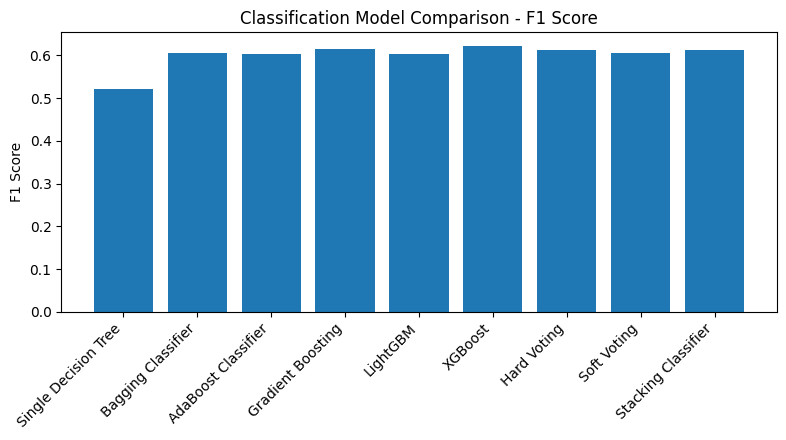

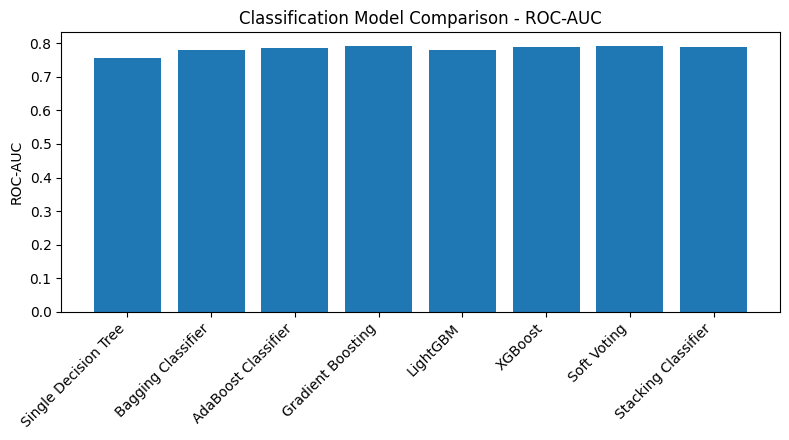

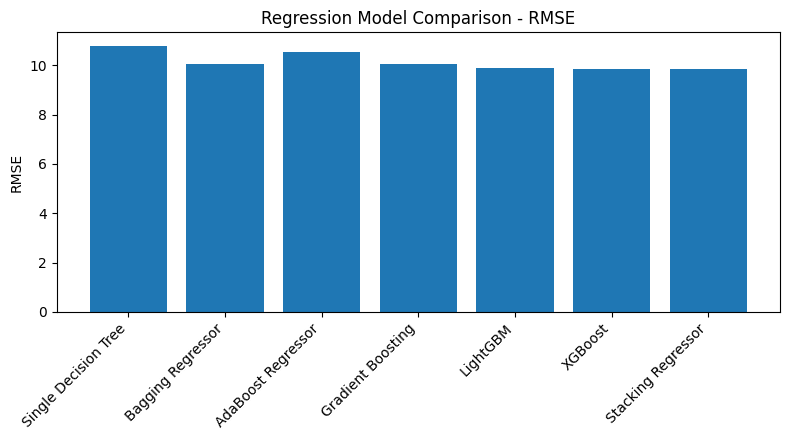

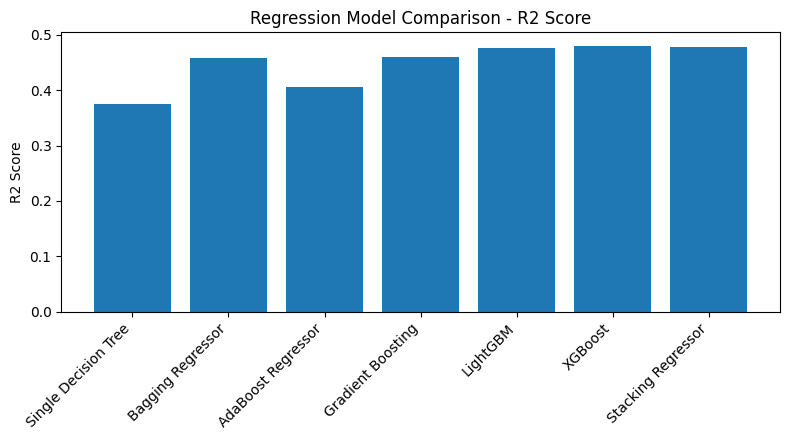

In [ ]:
plt.figure(figsize=(8,4.5))
plt.bar(final_classification["Model"], final_classification["F1"])
plt.title("Classification Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

soft_auc = final_classification.copy()
soft_auc = soft_auc.dropna(subset=["ROC_AUC"])

plt.figure(figsize=(8,4.5))
plt.bar(soft_auc["Model"], soft_auc["ROC_AUC"])
plt.title("Classification Model Comparison - ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
plt.bar(final_regression["Model"], final_regression["RMSE"])
plt.title("Regression Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
plt.bar(final_regression["Model"], final_regression["R2"])
plt.title("Regression Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Part F - Evaluation and Part G - Final Analysis

### Classification interpretation

The best **accuracy** in this run is from Hard Voting. The best **F1 score** is from XGBoost, while Soft Voting gives the highest ROC-AUC. This means the choice depends on the business goal. For ranking students by risk and then selecting a practical probability threshold, Soft Voting is a useful deployment choice.

### Regression interpretation

XGBoost gives the lowest RMSE and the highest R2 in this run, while Stacking Regressor has a slightly lower MAE. Because RMSE penalizes larger prediction errors and XGBoost is also fast on this dataset, it is recommended for the final score prediction.

### Bagging vs Boosting

Bagging improves the single-tree baseline by averaging several trees, mainly making the model more stable. Boosting generally gives stronger predictive performance because the trees are built sequentially and focus on the remaining errors.

### Voting vs Stacking

Voting is simple and transparent because the final decision comes directly from the base models. Stacking is more flexible because a meta-learner learns how to combine model outputs, but it is also more computationally expensive.

### Deployment recommendation

- **Course completion:** Soft Voting Classifier for a probability-based student risk score. A production system should select the final threshold using validation data and the cost of missed at-risk students.
- **Final score:** XGBoost Regressor because it has the best RMSE and R2 in this experiment.

The results are based on one fixed train-test split, so a future production version should also use cross-validation and ongoing monitoring.


In [ ]:
df["attendance_band"] = pd.cut(
    df["attendance_rate"],
    bins=[0, 0.70, 0.85, 0.95, 1.00],
    labels=["<70%", "70-85%", "85-95%", "95-100%"],
    include_lowest=True
)

attendance_summary = df.groupby("attendance_band", observed=False).agg(
    completion_rate=("completion_status", "mean"),
    avg_final_score=("final_score", "mean"),
    students=("final_score", "size")
).reset_index()

course_level_summary = df.groupby("course_level").agg(
    completion_rate=("completion_status", "mean"),
    avg_final_score=("final_score", "mean"),
    students=("final_score", "size")
).reset_index()

print("Attendance summary")
display(attendance_summary.round(3))

print("Course level summary")
display(course_level_summary.round(3))


Attendance summary


,attendance_band,completion_rate,avg_final_score,students
0,<70%,0.149,66.828,562
1,70-85%,0.290,72.597,1915
2,85-95%,0.438,76.670,1486
3,95-100%,0.545,79.992,1157


Course level summary


,course_level,completion_rate,avg_final_score,students
0,Advanced,0.349,74.467,860
1,Beginner,0.394,75.215,2264
2,Intermediate,0.366,74.539,2076


## Problem Statement and Objectives

### Problem Statement
The task is to build an ensemble-based machine learning system that predicts student outcomes from the supplied EdTech dataset. The system must handle both a classification problem and a regression problem.

### Objectives
1. Predict whether a student completes the course.
2. Predict the final performance score of a student.
3. Compare a single decision tree with bagging.
4. Implement AdaBoost, Gradient Boosting, LightGBM and XGBoost.
5. Implement Hard Voting, Soft Voting and Stacking for classification.
6. Implement Stacking Regressor for score prediction.
7. Compare the models using appropriate evaluation metrics.
8. Interpret the results and recommend a model for practical use.

## Data Preparation Notes

- `student_id` is treated as an identifier and is removed.
- `final_score` is excluded from classification features because it is the second target.
- `completion_status` is excluded from regression features for the same reason.
- `course_start_date` is converted into `start_month` and `start_day`.
- Missing numeric values are handled with median imputation.
- Missing categorical values are handled with most-frequent imputation.
- Categorical variables are one-hot encoded.
- Numeric scaling is available in the preprocessing function for models that need it.
- Classification uses a stratified 80/20 train-test split with `random_state=42`; regression uses an 80/20 split with the same random seed.

These steps are kept inside scikit-learn pipelines so preprocessing is applied consistently during model fitting and prediction.

## Evaluation Metric Notes

### Classification
**Accuracy** shows the overall fraction of correct predictions.

**Precision** shows how many predicted positive cases were actually positive.

**Recall** shows how many actual positive cases were correctly identified.

**F1 score** balances precision and recall and is useful when both types of error matter.

**ROC-AUC** measures how well the model ranks positive cases above negative cases across probability thresholds.

### Regression
**MAE** gives the average absolute prediction error.

**RMSE** gives more weight to larger errors.

**R²** measures how much of the variance in the target is explained by the model.

## Final Analysis / Part F and Part G

### Bagging vs Boosting
Bagging improved the stability of the single-tree approach by averaging multiple trees trained on bootstrap samples. Boosting approaches were generally stronger because each new learner focuses on remaining prediction errors. The exact winner depends on the evaluation metric.

### Comparison of Tree-Based Boosting Algorithms
AdaBoost uses sequential weak learners and changes the importance of training examples. Gradient Boosting builds trees sequentially using a gradient-based loss minimization idea. LightGBM is designed for efficient gradient boosting with tree-based learning, while XGBoost adds regularization and other practical improvements. On this dataset, XGBoost produced the strongest regression result among the tested models.

### Advantages of Voting
Voting is simple and easy to explain. Hard voting is based on majority decisions. Soft voting uses the probability information from each model and can therefore give a better ranking signal.

### Advantages of Stacking
Stacking can learn when one base model is more useful than another. Instead of simply averaging predictions, the meta-learner learns from the outputs of the base learners. The trade-off is additional complexity and training time.

### Classification Recommendation
In the executed run, Hard Voting achieved the highest accuracy, XGBoost achieved the highest F1 score, and Soft Voting achieved the highest ROC-AUC. For a deployment situation where ranking students by completion risk is important, Soft Voting is a practical choice because it provides probability information.

### Regression Recommendation
XGBoost achieved the lowest RMSE and the highest R² in the executed run. Stacking Regressor gave a slightly lower MAE. Since RMSE penalizes larger errors and XGBoost showed the strongest overall regression profile, XGBoost is recommended for final score prediction.

### Practical Interpretation
The model should be treated as a decision-support tool rather than as a final judgment about a student. Predictions can help identify students who may need additional academic support, but actual interventions should also consider instructor observations and other context.

## Conclusion

This project shows how ensemble learning can be used for two related student-outcome prediction tasks. Bagging provides a stable alternative to one decision tree, while boosting can improve predictive strength by correcting errors sequentially. Voting gives a simple way to combine different classifiers and stacking adds a meta-learning layer to the ensemble.

Based on the executed results, the recommended final setup is **Soft Voting for completion-risk probability** and **XGBoost for final-score prediction**. These choices balance predictive performance with a practical interpretation of the evaluation metrics.